# Gene Expression Cancer Data Analysis

## Step 1: Loading and Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('E:\Python\gene expression RNA seq data.csv')

print(df.shape)
print(df.head())

<>:7: SyntaxWarning: invalid escape sequence '\P'
<>:7: SyntaxWarning: invalid escape sequence '\P'
C:\Users\khan\AppData\Local\Temp\ipykernel_186376\1888482903.py:7: SyntaxWarning: invalid escape sequence '\P'
  df = pd.read_csv('E:\Python\gene expression RNA seq data.csv')


(801, 20532)
  Unnamed: 0  gene_0    gene_1    gene_2    gene_3     gene_4  gene_5  \
0   sample_0     0.0  2.017209  3.265527  5.478487  10.431999     0.0   
1   sample_1     0.0  0.592732  1.588421  7.586157   9.623011     0.0   
2   sample_2     0.0  3.511759  4.327199  6.881787   9.870730     0.0   
3   sample_3     0.0  3.663618  4.507649  6.659068  10.196184     0.0   
4   sample_4     0.0  2.655741  2.821547  6.539454   9.738265     0.0   

     gene_6    gene_7  gene_8  ...  gene_20521  gene_20522  gene_20523  \
0  7.175175  0.591871     0.0  ...    4.926711    8.210257    9.723516   
1  6.816049  0.000000     0.0  ...    4.593372    7.323865    9.740931   
2  6.972130  0.452595     0.0  ...    5.125213    8.127123   10.908640   
3  7.843375  0.434882     0.0  ...    6.076566    8.792959   10.141520   
4  6.566967  0.360982     0.0  ...    5.996032    8.891425   10.373790   

   gene_20524  gene_20525  gene_20526  gene_20527  gene_20528  gene_20529  \
0    7.220030    9.119813 

## Step 2: Data Quality Check

In [2]:
# Check missing values
print("Missing values:", df.isnull().sum().sum())

# Check data types
print("\nData types:")
print(df.dtypes.value_counts())

# Basic statistics
print("\nBasic stats:")
print(df.iloc[:, 1:6].describe())

# Check if labels file exists
import os
files = os.listdir(os.getcwd())
for f in files:
    if 'label' in f.lower() or 'class' in f.lower():
        print("Found label file:", f)

Missing values: 0

Data types:
float64    20531
object         1
Name: count, dtype: int64

Basic stats:
           gene_0      gene_1      gene_2      gene_3      gene_4
count  801.000000  801.000000  801.000000  801.000000  801.000000
mean     0.026642    3.010909    3.095350    6.722305    9.813612
std      0.136850    1.200828    1.065601    0.638819    0.506537
min      0.000000    0.000000    0.000000    5.009284    8.435999
25%      0.000000    2.299039    2.390365    6.303346    9.464466
50%      0.000000    3.143687    3.127006    6.655893    9.791599
75%      0.000000    3.883484    3.802534    7.038447   10.142324
max      1.482332    6.237034    6.063484   10.129528   11.355621


## Step 3: Load Cancer Type Labels

In [3]:
# Load labels
labels = pd.read_csv('E:\Python\labels.csv')

print(labels.shape)
print(labels.head())
print("\nCancer types:")
print(labels.iloc[:, 1].value_counts())

(801, 2)
  Unnamed: 0 Class
0   sample_0  PRAD
1   sample_1  LUAD
2   sample_2  PRAD
3   sample_3  PRAD
4   sample_4  BRCA

Cancer types:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64


<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\khan\AppData\Local\Temp\ipykernel_186376\3242573273.py:2: SyntaxWarning: invalid escape sequence '\P'
  labels = pd.read_csv('E:\Python\labels.csv')


## Step 4: Merge Gene Expression Data with Cancer Labels

In [4]:
# Rename column for clarity
labels.columns = ['sample_id', 'cancer_type']
df.rename(columns={'Unnamed: 0': 'sample_id'}, inplace=True)

# Merge
df_merged = pd.merge(df, labels, on='sample_id')

print("Merged shape:", df_merged.shape)
print(df_merged[['sample_id', 'cancer_type']].head())

Merged shape: (801, 20533)
  sample_id cancer_type
0  sample_0        PRAD
1  sample_1        LUAD
2  sample_2        PRAD
3  sample_3        PRAD
4  sample_4        BRCA


## Step 5: Cancer Type Distribution

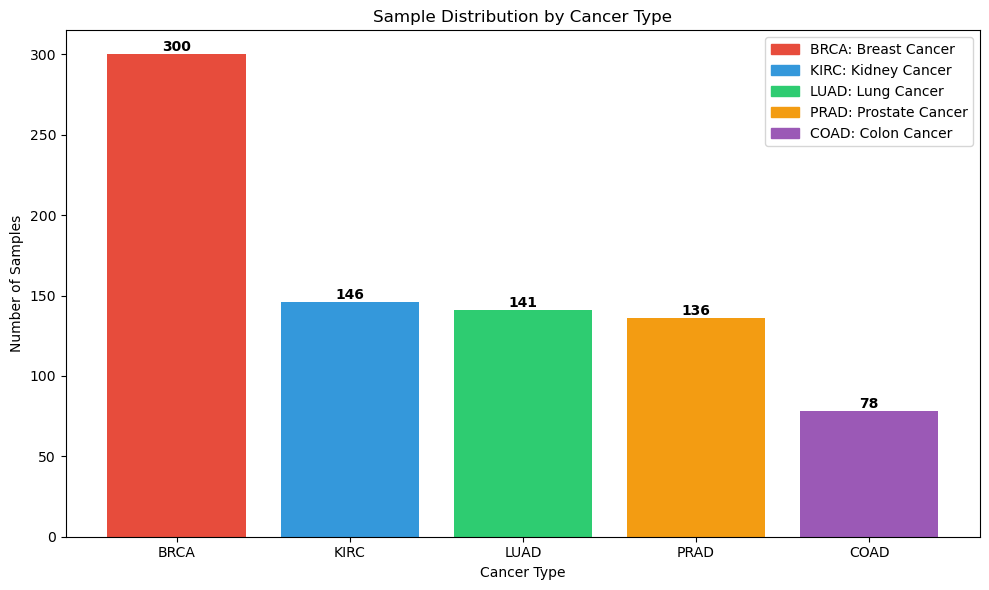

In [6]:
plt.figure(figsize=(10, 6))
cancer_counts = df_merged['cancer_type'].value_counts()

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
bars = plt.bar(cancer_counts.index, cancer_counts.values, color=colors)

plt.title('Sample Distribution by Cancer Type')
plt.xlabel('Cancer Type')
plt.ylabel('Number of Samples')

# Add value labels on top
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Fixed legend
legend_labels = ['BRCA: Breast Cancer', 'KIRC: Kidney Cancer',
                 'LUAD: Lung Cancer', 'PRAD: Prostate Cancer',
                 'COAD: Colon Cancer']

handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(5)]
plt.legend(handles, legend_labels, loc='upper right')

plt.tight_layout()
plt.show()

## Step 6: Heatmap of Top 50 Most Variable Genes

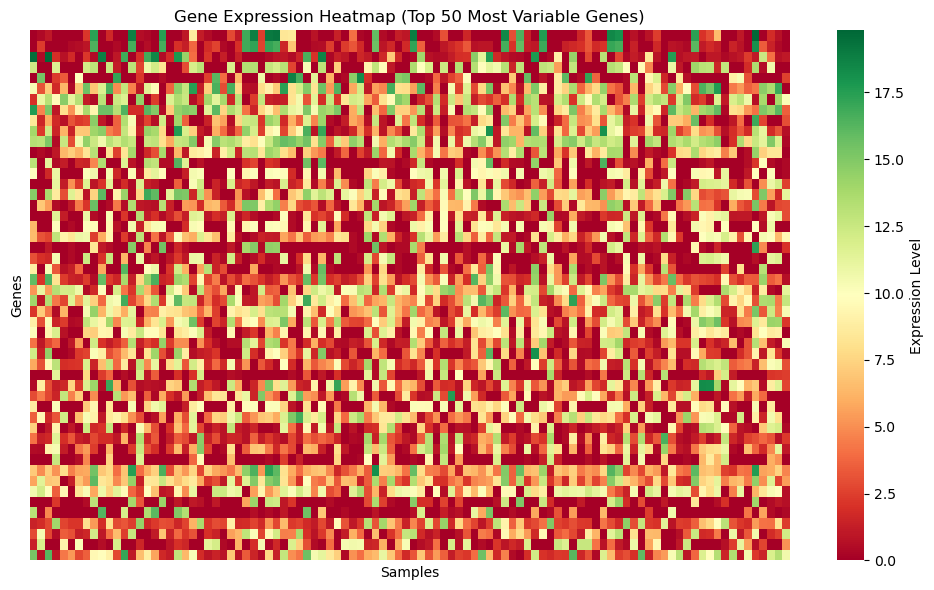

In [8]:
# Get gene columns only
gene_cols = [col for col in df_merged.columns 
             if col.startswith('gene_')]

# Find top 50 most variable genes
gene_variance = df_merged[gene_cols].var().nlargest(50).index

# Sample 100 rows for cleaner visualization
df_sample = df_merged.sample(100, random_state=42)

# Create heatmap data
heatmap_data = df_sample[gene_variance].T

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, 
            cmap='RdYlGn',
            xticklabels=False,
            yticklabels=False,
            cbar_kws={'label': 'Expression Level'})

plt.title('Gene Expression Heatmap (Top 50 Most Variable Genes)')
plt.xlabel('Samples')
plt.ylabel('Genes')
plt.tight_layout()
plt.show()

## Step 7: Average Gene Expression by Cancer Type

<Figure size 1400x600 with 0 Axes>

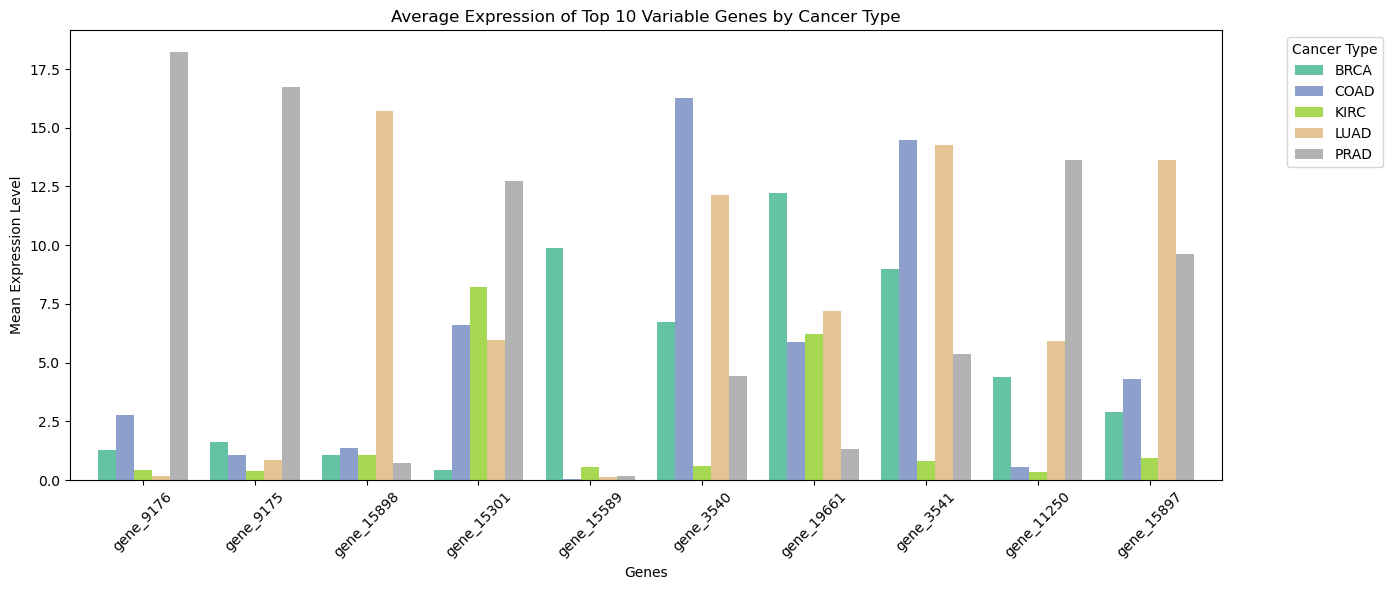

In [11]:
# Calculate mean expression for top 10 most variable genes
top10_genes = df_merged[gene_cols].var().nlargest(10).index

# Get mean expression per cancer type
cancer_gene_mean = df_merged.groupby('cancer_type')[top10_genes].mean()

# Plot
plt.figure(figsize=(14, 6))
cancer_gene_mean.T.plot(kind='bar', figsize=(14, 6), 
                         colormap='Set2', width=0.8)

plt.title('Average Expression of Top 10 Variable Genes by Cancer Type')
plt.xlabel('Genes')
plt.ylabel('Mean Expression Level')
plt.legend(title='Cancer Type', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 8: Gene Expression Distribution by Cancer Type

C:\Users\khan\AppData\Local\Temp\ipykernel_186376\632202322.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=cancer_types, patch_artist=True)


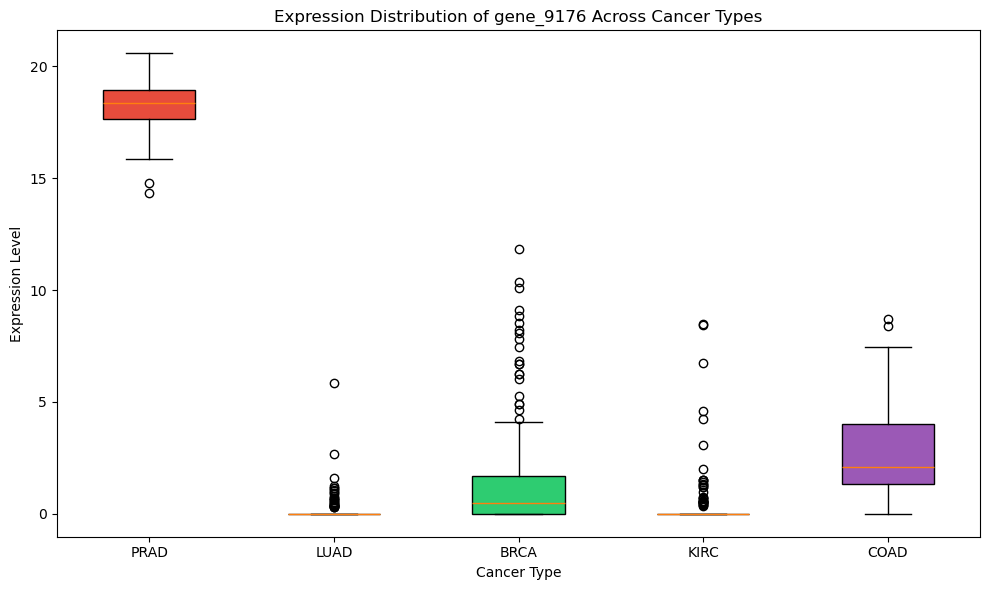

In [12]:
# Pick top 1 most variable gene
top_gene = df_merged[gene_cols].var().nlargest(1).index[0]

plt.figure(figsize=(10, 6))
cancer_types = df_merged['cancer_type'].unique()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

data_to_plot = [df_merged[df_merged['cancer_type'] == ct][top_gene].values 
                for ct in cancer_types]

bp = plt.boxplot(data_to_plot, labels=cancer_types, patch_artist=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title(f'Expression Distribution of {top_gene} Across Cancer Types')
plt.xlabel('Cancer Type')
plt.ylabel('Expression Level')
plt.tight_layout()
plt.show()

## Step 9: Project Summary

In [13]:
print("=" * 55)
print("GENE EXPRESSION ANALYSIS SUMMARY")
print("=" * 55)
print(f"Total Samples: {df_merged.shape[0]}")
print(f"Total Genes Analyzed: {len(gene_cols)}")
print(f"Cancer Types: {df_merged['cancer_type'].nunique()}")
print(f"\nSamples per Cancer Type:")
print(df_merged['cancer_type'].value_counts().to_string())
print(f"\nMost Variable Gene: {top_gene}")
print(f"Missing Values: 0")
print("=" * 55)

GENE EXPRESSION ANALYSIS SUMMARY
Total Samples: 801
Total Genes Analyzed: 20531
Cancer Types: 5

Samples per Cancer Type:
cancer_type
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78

Most Variable Gene: gene_9176
Missing Values: 0
